I was inspired by [@twieky](https://github.com/twiecki) and his great [post](http://twiecki.github.io/blog/2016/07/05/bayesian-deep-learning/) about bayesian neural networks. But I thought that that way of creating BNNs is not obvious and easy for people. That's why I decided to make a bridge for `PyMC3` and `Lasagne`.
I will use his convolution bnn from the post as an example of how to use gelato API

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import gelato
import theano
import theano.tensor as tt
theano.config.warn_float64 = 'warn'
import numpy as np
import lasagne
import pymc3 as pm

WARNING (theano.sandbox.cuda): The cuda backend is deprecated and will be removed in the next release (v0.10).  Please switch to the gpuarray backend. You can get more information about how to switch at this URL:
 https://github.com/Theano/Theano/wiki/Converting-to-the-new-gpu-back-end%28gpuarray%29

Using gpu device 0: Tesla K40m (CNMeM is enabled with initial size: 95.0% of memory, cuDNN 4007)


## Load Data

In [2]:
import sys, os

def load_dataset():
    # We first define a download function, supporting both Python 2 and 3.
    if sys.version_info[0] == 2:
        from urllib import urlretrieve
    else:
        from urllib.request import urlretrieve

    def download(filename, source='http://yann.lecun.com/exdb/mnist/'):
        print("Downloading %s" % filename)
        urlretrieve(source + filename, filename)

    # We then define functions for loading MNIST images and labels.
    # For convenience, they also download the requested files if needed.
    import gzip

    def load_mnist_images(filename):
        if not os.path.exists(filename):
            download(filename)
        # Read the inputs in Yann LeCun's binary format.
        with gzip.open(filename, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
        # The inputs are vectors now, we reshape them to monochrome 2D images,
        # following the shape convention: (examples, channels, rows, columns)
        data = data.reshape(-1, 1, 28, 28)
        # The inputs come as bytes, we convert them to float32 in range [0,1].
        # (Actually to range [0, 255/256], for compatibility to the version
        # provided at http://deeplearning.net/data/mnist/mnist.pkl.gz.)
        return data / np.float32(256)

    def load_mnist_labels(filename):
        if not os.path.exists(filename):
            download(filename)
        # Read the labels in Yann LeCun's binary format.
        with gzip.open(filename, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=8)
        # The labels are vectors of integers now, that's exactly what we want.
        return data

    # We can now download and read the training and test set images and labels.
    X_train = load_mnist_images('train-images-idx3-ubyte.gz')
    y_train = load_mnist_labels('train-labels-idx1-ubyte.gz')
    X_test = load_mnist_images('t10k-images-idx3-ubyte.gz')
    y_test = load_mnist_labels('t10k-labels-idx1-ubyte.gz')

    # We reserve the last 10000 training examples for validation.
    X_train, X_val = X_train[:-10000], X_train[-10000:]
    y_train, y_val = y_train[:-10000], y_train[-10000:]

    # We just return all the arrays in order, as expected in main().
    # (It doesn't matter how we do this as long as we can read them again.)
    return X_train, y_train, X_val, y_val, X_test, y_test

print("Loading data...")
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset()
total_size = X_train.shape[0]

Loading data...


## Minibatches
I prefer storing all my dataset in GPU memory if it is possible to avoid unnessesary data transfers. Thus I use a bit strange minibatch generation but it worths.

In [3]:
input_var = theano.shared(X_train.astype(np.float32))
target_var = theano.shared(y_train.astype(np.float32))
# random indeces with fixed batch size
ridx = gelato.random.tt_rng().uniform(low=0, high=total_size-1e-16, size=(128,)).astype('int32')
input_var=input_var[ridx]
target_var=target_var[ridx]

## Create priors for weights
Gelato has a flexible way to define a prior on weight instead of just shared variable. That allows to deal with uncertanty in weights and in predictions as well. 
### Disclamer
I have to note that Gelato has some overhead magic with wrappring lasagne layers. Espessially there is no need to use gelato layer if you pass gelato `Spec` class to lasagne layer to define a weight. But using them happens to be very convenient. There is a handy function `set_default_spec` that declares what prior to use if none specified.

## Priors
In this setup I decided to use hyperprior to show it can be done very easily

In [4]:
from gelato.specs import NormalSpec, LognormalSpec, set_default_spec
# Now every layer without passed specs will use `NormalSpec(sd=hyper)` as a prior
hyper = LognormalSpec(sd=1).with_shape(())
set_default_spec(NormalSpec(sd=hyper))

## Network

The following print output should make you think *"What's the hell is going on? Is it real?"*

In [5]:
print(issubclass(gelato.layers.InputLayer, pm.Model) and 
      issubclass(gelato.layers.Conv2DLayer, pm.Model))
print(issubclass(gelato.layers.InputLayer, lasagne.layers.Layer) and 
      issubclass(gelato.layers.Conv2DLayer, lasagne.layers.Layer))

True
True


Yes, Gelato layers are Models and Layers at the same time. Moreover contest is taken from the previous layers so that you no more need `modelcontext` for most usecases.

In [6]:
network = gelato.layers.InputLayer(shape=(None, 1, 28, 28),
                                    input_var=input_var)

network = gelato.layers.Conv2DLayer(
        network, num_filters=32, filter_size=(5, 5),
        nonlinearity=lasagne.nonlinearities.tanh)

# Max-pooling layer of factor 2 in both dimensions:
network = gelato.layers.MaxPool2DLayer(network, pool_size=(2, 2))

# Another convolution with 32 5x5 kernels, and another 2x2 pooling:
network = gelato.layers.Conv2DLayer(
    network, num_filters=32, filter_size=(5, 5),
    nonlinearity=lasagne.nonlinearities.tanh)

network = gelato.layers.MaxPool2DLayer(network, 
                                        pool_size=(2, 2))

n_hid2 = 176
network = gelato.layers.DenseLayer(
    network, num_units=n_hid2,
    nonlinearity=lasagne.nonlinearities.tanh,
)

n_hid3 = 64
network = gelato.layers.DenseLayer(
    network, num_units=n_hid3,
    nonlinearity=lasagne.nonlinearities.tanh,
)

# Finally, we'll add the fully-connected output layer, of 10 softmax units:
network = gelato.layers.DenseLayer(
    network, num_units=10,
    nonlinearity=lasagne.nonlinearities.softmax,
)

prediction = gelato.layers.get_output(network)

# Gelato layers are designed to simlify the whole process
# and are pm.Models as well as lasagne.layer.Layer
# You can work in the contest of the last defined layer to define likelihood
with network:
    likelihood = pm.Categorical('out', 
                   prediction,
                   observed=target_var,
                   total_size=total_size)

We now minimize the following objective
$$ELBO=pi*KL[q(w|mu,rho)||p(w)] + E_q[log p(D|w)]$$

Getting ELBO for model and optimizing it is quite easy and can be cone just in few lines. As we will perform batch training we have to say what population size we have for observed var or else we'll get invalid approximation.

Let's see what we've created

In [8]:
network.vars

[DenseLayer_140554271961040_W:32_log__,
 DenseLayer_140554271961040_W,
 DenseLayer_140554271961040_b:36_log__,
 DenseLayer_140554271961040_b]

Seems something went wrong:(

That's not the thing you expect, but that's just a nested model.
You can find your root model accessing `network.root`. It stores all parameters, porentials, likelihood, etc

In [9]:
network.root.vars

[Conv2DLayer_140554279269768_W:0_log__,
 Conv2DLayer_140554279269768_W,
 Conv2DLayer_140554279269768_b:4_log__,
 Conv2DLayer_140554279269768_b,
 Conv2DLayer_140554279272232_W:8_log__,
 Conv2DLayer_140554279272232_W,
 Conv2DLayer_140554279272232_b:12_log__,
 Conv2DLayer_140554279272232_b,
 DenseLayer_140554272564896_W:16_log__,
 DenseLayer_140554272564896_W,
 DenseLayer_140554272564896_b:20_log__,
 DenseLayer_140554272564896_b,
 DenseLayer_140554233385872_W:24_log__,
 DenseLayer_140554233385872_W,
 DenseLayer_140554233385872_b:28_log__,
 DenseLayer_140554233385872_b,
 DenseLayer_140554271961040_W:32_log__,
 DenseLayer_140554271961040_W,
 DenseLayer_140554271961040_b:36_log__,
 DenseLayer_140554271961040_b]

## Inference

In [10]:
# I prefer object oriented style for doing inference in PyMC3 as it allows more flexibility
# Remember that we need root model here
with network.root:
    advi = pm.ADVI()

In [12]:
advi.fit(80000) # that's going to be enough

/home/ferres/.pyenv/versions/3.5.0/lib/python3.5/site-packages/theano/tensor/var.py:819: UserWarning: You are creating a TensorVariable with float64 dtype. You requested an action via the Theano flag warn_float64={ignore,warn,raise,pdb}.
  warnings.warn(msg, stacklevel=1 + nb_rm)
INFO (theano.gof.compilelock): Refreshing lock /home/ferres/.theano/compiledir_Linux-3.10--x86_64-with-debian-wheezy-sid-x86_64-3.5.0-64/lock_dir/lock
INFO (theano.gof.compilelock): Refreshing lock /home/ferres/.theano/compiledir_Linux-3.10--x86_64-with-debian-wheezy-sid-x86_64-3.5.0-64/lock_dir/lock
INFO (theano.gof.compilelock): Refreshing lock /home/ferres/.theano/compiledir_Linux-3.10--x86_64-with-debian-wheezy-sid-x86_64-3.5.0-64/lock_dir/lock
/home/ferres/.pyenv/versions/3.5.0/lib/python3.5/site-packages/theano/tensor/var.py:819: UserWarning: You are creating a TensorVariable with float64 dtype. You requested an action via the Theano flag warn_float64={ignore,warn,raise,pdb}.
  warnings.warn(msg, stackle

I see some variables are going to be float64, it is WIP to prevent upcasting. You can treat it as field of potential improvement

Model was about to converge, I saw that loss was still going down. One can continue to fit the network

In [9]:
import pickle
#params = advi.approx.shared_params
#pickle.dump(params, open('params.pymc3','wb'))

In [10]:
#advi.approx.shared_params = pickle.load(open('params.pymc3','rb'))

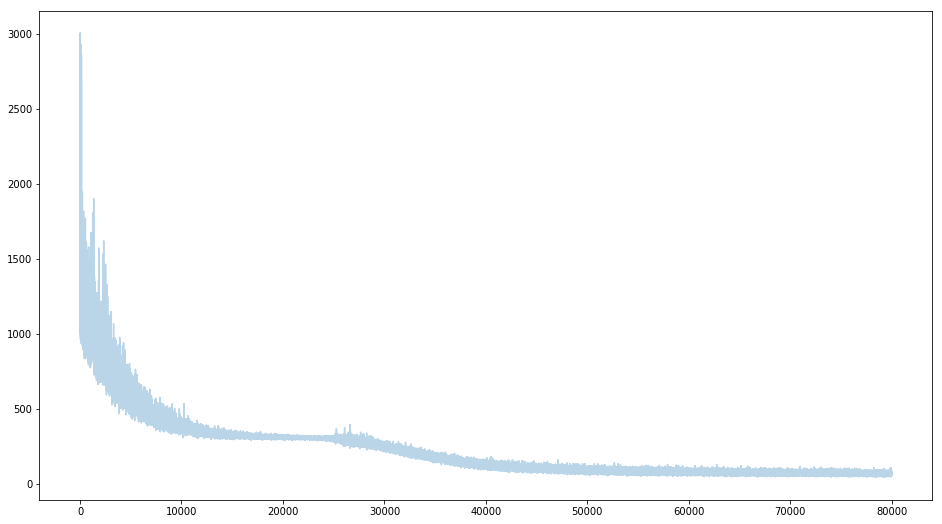

In [13]:
plt.figure(figsize=(16,9))
plt.plot(np.array(advi.hist), alpha=.3);

# Important to note
Calling `lasagne.layers.get_output` we in fact get symbolic outpuc of the model. The inferred approximation is not yet applied. Good news are that `pymc3.variatonal` is designed to meet the needs of Bayesian deep learning. It is pretty easy to make it work with minimal efforts and lines of code.

In [14]:
from theano.configparser import change_flags

# The right way to compile a function without changing important pymc3 flag `compute_test_value='raise'`
with change_flags(compute_test_value='ignore'):
    inpimg = tt.tensor4('input')
    it = tt.iscalar('i')
    _prediction = gelato.layers.get_output(network)
    prediction = advi.approx.apply_replacements(_prediction, deterministic=True, more_replacements={input_var:inpimg})
    predictions = advi.approx.sample_node(_prediction, it, more_replacements={input_var:inpimg})
    predictions_f = theano.function([inpimg, theano.In(it, 's', 10)], predictions)
    prediction_f = theano.function([inpimg], prediction)

INFO (theano.gof.compilelock): Refreshing lock /home/ferres/.theano/compiledir_Linux-3.10--x86_64-with-debian-wheezy-sid-x86_64-3.5.0-64/lock_dir/lock


## Making predictions

There are different approaches to make decidions under Bayesian setup. One can use __MAP__ esimation for prediction, other options are to use mean of the posterior or predict distribution and integrate out the mean or mode. I'll compare MAP and posterior predictive mode

In [51]:
from scipy.stats import mode
y_pred_MAP = np.argmax(prediction_f(X_test), axis=1)
error_under_MAP = y_pred_MAP != y_test
error_rate_under_MAP = error_under_MAP.mean()

y_preds_posterior = predictions_f(X_test, 100)
y_pred_posterior = mode(np.argmax(y_preds_posterior, axis=-1), axis=0).mode[0]
error_under_posterior = y_pred_posterior != y_test
error_rate_under_posterior = error_under_posterior.mean()

In [52]:
print('MAP                      : %f' % error_rate_under_MAP)
print('predictive posterior mode: %f' % error_rate_under_posterior)

MAP                      : 0.044800
predictive posterior mode: 0.041900


Seems like MAP estimation may be not the best way to predict. On the other hand it is much faster

In [56]:
def check_the_error_at(idx):
    print('true:', y_test[error_under_posterior][idx],'prediction:', y_pred[error_under_posterior][idx])
    plt.gray();plt.matshow(X_test[error_under_posterior][idx][0]);plt.show();

true: 3 prediction: 8


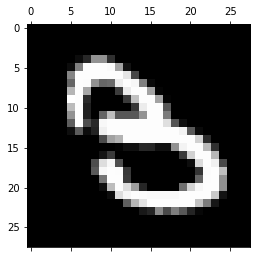

In [57]:
check_the_error_at(0)

true: 4 prediction: 6


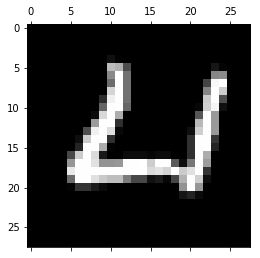

In [58]:
check_the_error_at(1)

# Uncertainty
From a glance uncertainty is not important. But I'll show that it can used for making decisions.


## Simple variance 
Let's calculate average variance in correct pedictions and wrong predictions. I don't use Chi squared statistics to illustrate the difference as [@twieky](https://github.com/twiecki) did. But still, this picture gives an evidence that mistakes are done with more quantity of uncertanty and thus can be potentially treated as problebatic examples 

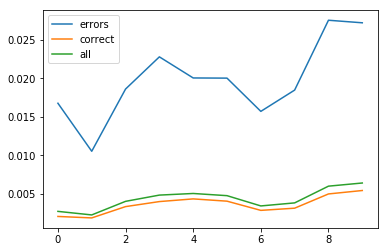

In [59]:
plt.plot(sampled_preds.var(0)[errors].mean(0), label='errors')
plt.plot(sampled_preds.var(0)[~errors].mean(0), label='correct')
plt.plot(sampled_preds.var(0).mean(0), label='all')
plt.legend()

Wow, variance seems to be much higher for problematic examples

## Expected error rate

We can get the posterior distribution for predictions. That gives a lot of information for us. When we constructed `y_pred_posterior` we minimized that expected rate of error, taking tha mode of the distribution. Note that is true for categorical predictions. For regression problem with L2 loss one preferes to integrate out mean of the posterior.

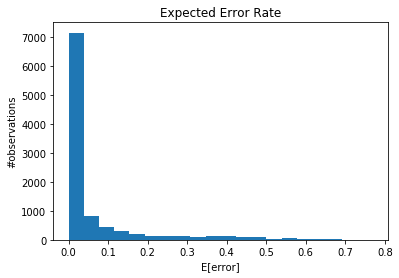

In [74]:
y_preds_labels = np.argmax(y_preds_posterior, axis=-1)
prediction_expected_error_rate = (y_preds_labels != y_pred_posterior).mean(0)
plt.hist(prediction_expected_error_rate, bins=20)
plt.title('Expected Error Rate');
plt.xlabel('E[error]')
plt.ylabel('#observations')

Seems like our model is not always confident in predictions and is aware of it. Let's check how often it happens so

In [75]:
((prediction_expected_error_rate != 0) == error_under_posterior).mean()

0.53300000000000003

In 53% cases our model is not confident enough that fact leeds to mistake. 

## High confident errors
Next. How often is out model overconfident? In other words it seems all to be okay but we have an error.

In [77]:
(prediction_expected_error_rate[error_under_posterior] == 0).mean()

0.0071599045346062056

Good news, It happens pretty rare, exactly 3 times.

In [78]:
(prediction_expected_error_rate[error_under_posterior] == 0).sum()

3

In [79]:
houston_we_have_a_problem = prediction_expected_error_rate[error_under_posterior] == 0

In [87]:
def problem_display():
    for i in range(houston_we_have_a_problem.sum()):
        print('true:', y_test[error_under_posterior][houston_we_have_a_problem][i],
              'prediction:', y_pred_posterior[error_under_posterior][houston_we_have_a_problem][i])
        plt.gray();plt.matshow(X_test[error_under_posterior][houston_we_have_a_problem][i][0]);plt.show();

true: 7 prediction: 2


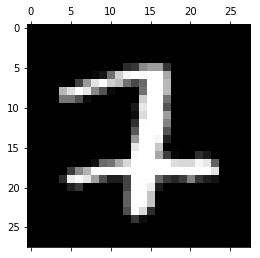

true: 6 prediction: 4


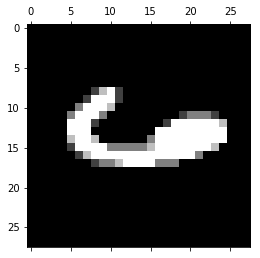

true: 7 prediction: 2


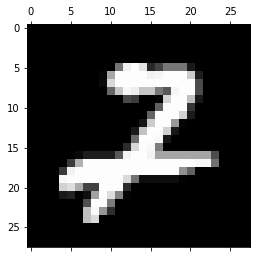

In [86]:
problem_display()

Now we see that The problem is on "7" numbers.

## Low confidence predictions

In [99]:
top_three = np.argsort(prediction_expected_error_rate)[-3:][::-1]

In [100]:
top_three

array([4966, 1952, 4176])

In [107]:
def low_confidence_examples_display():
    for i in top_three:
        print('true:', y_test[i],
              'prediction:', y_pred_posterior[i],
              'expected error rate:', prediction_expected_error_rate[i]
             )
        plt.gray();plt.matshow(X_test[i][0]);plt.show();

true: 7 prediction: 3 expected error rate: 0.77


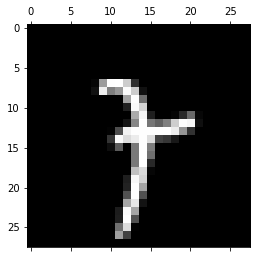

true: 9 prediction: 5 expected error rate: 0.72


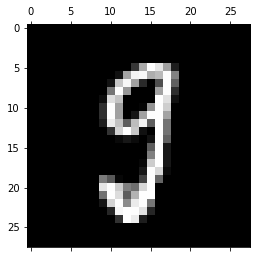

true: 2 prediction: 7 expected error rate: 0.71


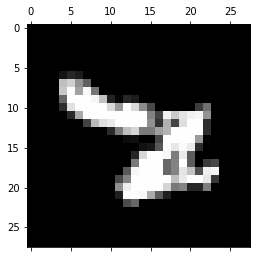

In [106]:
low_confidence_examples_display()

That's done, I hope now model confidence does not seem such vague. Thank you for reading.